# 01 — Probability Basics
**Week 2 | Mathematical Foundations for RL**

By the end of this notebook you will:
- Simulate discrete and continuous random variables
- Compute empirical mean, variance, and compare to theoretical values
- Visualise distributions and understand their shape

These are the building blocks for understanding stochastic rewards in RL.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. Dice Simulation
A fair 6-sided die — simplest discrete random variable.

Empirical mean:     3.4999  (theoretical: 3.5000)
Empirical variance: 2.9194  (theoretical: 2.9167)


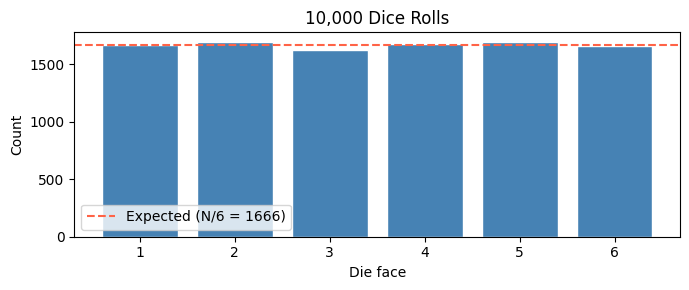

In [14]:
# Simulate N dice rolls
N = 10_000
rolls = np.random.randint(1, 7, size=N)

# Theoretical values
theoretical_mean = 3.5
theoretical_var  = 35/12  # (b-a+1)^2 - 1) / 12 for uniform discrete

print(f"Empirical mean:     {rolls.mean():.4f}  (theoretical: {theoretical_mean:.4f})")
print(f"Empirical variance: {rolls.var():.4f}  (theoretical: {theoretical_var:.4f})")

plt.figure(figsize=(7, 3))
counts, _, bars = plt.hist(rolls, bins=np.arange(0.5, 7.5, 1), edgecolor='white', color='steelblue', rwidth=0.8)
plt.axhline(N/6, color='tomato', linestyle='--', label=f'Expected (N/6 = {N//6})')
plt.xlabel('Die face'); plt.ylabel('Count'); plt.title('10,000 Dice Rolls')
plt.xticks(range(1,7)); plt.legend(); plt.tight_layout(); plt.show()

## 2. Continuous Distribution — Normal
Many RL reward signals are approximately Gaussian.

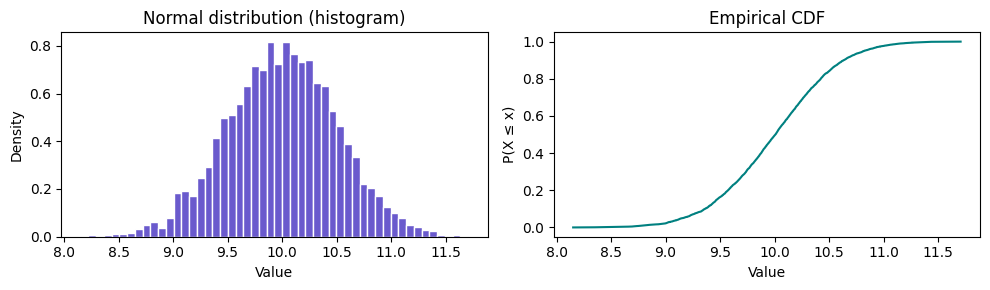

Mean: 9.999 (true: 10.0)
Std:  0.503  (true: 0.5)


In [15]:

N = 5000
mu, sigma = 10.0, 0.5
samples = np.random.normal(mu, sigma, size=N)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(samples, bins=50, color='slateblue', edgecolor='white', density=True)
axes[0].set_title('Normal distribution (histogram)')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density')

# Empirical CDF
sorted_s = np.sort(samples)
cdf = np.arange(1, N+1) / N
axes[1].plot(sorted_s, cdf, color='teal', linewidth=1.5)
axes[1].set_title('Empirical CDF')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('P(X ≤ x)')

plt.tight_layout(); plt.show()

print(f"Mean: {samples.mean():.3f} (true: {mu})")
print(f"Std:  {samples.std():.3f}  (true: {sigma})")

Basically, it comes down to sliding and squishing.$\mu$ (Mean): This just slides the whole histogram left or right along the x-axis. We changed it from 5 to 10, so the entire shape just picked up and moved to the right.$\sigma$ (Standard Deviation): This changes how "fat" or "skinny" the bell curve is. Because we dropped it from 1.5 down to 0.5, the data is forced to clump much closer to the mean. The histogram gets dramatically narrower and much taller (since the total area has to stay the same).

## 3. Expectation and Variance — Intuition
Expectation = centre of mass of the distribution.  
Variance = average squared distance from the mean (spread).

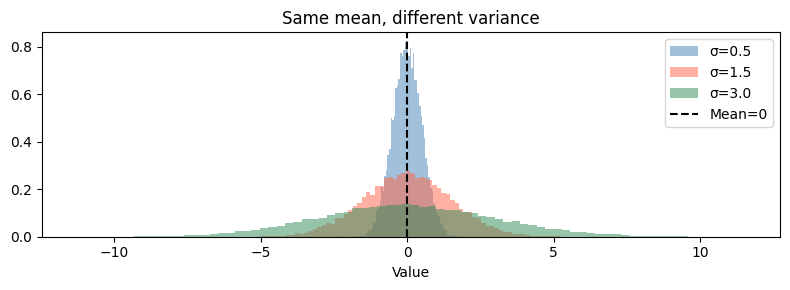

In [16]:
# Compare two distributions with same mean but different variance
fig, ax = plt.subplots(figsize=(8, 3))
for sigma_, color_, label_ in [(0.5,'steelblue','σ=0.5'), (1.5,'tomato','σ=1.5'), (3.0,'seagreen','σ=3.0')]:
    s = np.random.normal(0, sigma_, 20_000)
    ax.hist(s, bins=80, alpha=0.5, density=True, color=color_, label=label_)
ax.axvline(0, color='black', linestyle='--', label='Mean=0')
ax.set_title('Same mean, different variance'); ax.legend(); ax.set_xlabel('Value')
plt.tight_layout(); plt.show()

## 4. The Law of Large Numbers
As we collect more samples, the empirical mean converges to E[X].  
This is why RL agents improve with experience.

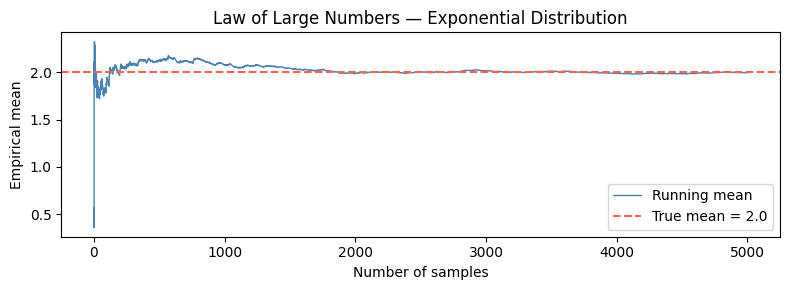

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# For an exponential distribution, the 'scale' parameter is exactly its mean.
true_mean = 2.0
samples_seq = np.random.exponential(scale=true_mean, size=5000)
running_mean = np.cumsum(samples_seq) / np.arange(1, 5001)

plt.figure(figsize=(8, 3))
plt.plot(running_mean, color='steelblue', linewidth=1, label='Running mean')
plt.axhline(true_mean, color='tomato', linestyle='--', label=f'True mean = {true_mean}')
plt.xlabel('Number of samples'); plt.ylabel('Empirical mean')
plt.title('Law of Large Numbers — Exponential Distribution')
plt.legend(); plt.tight_layout(); plt.show()

Yes, the Law of Large Numbers (LLN) absolutely still holds.

The LLN applies to any sequence of independent, identically distributed random variables as long as the distribution has a finite, well-defined expected value (mean). Since the exponential distribution has a finite mean, its running average will always converge to that true mean as your sample size grows.

The only visual difference you'll see is that the early fluctuations are often much wilder. Because the exponential distribution is heavily skewed and occasionally produces very large outliers, a few massive early values can yank the running mean way off course before the sheer volume of subsequent samples drags it back to the true mean line.

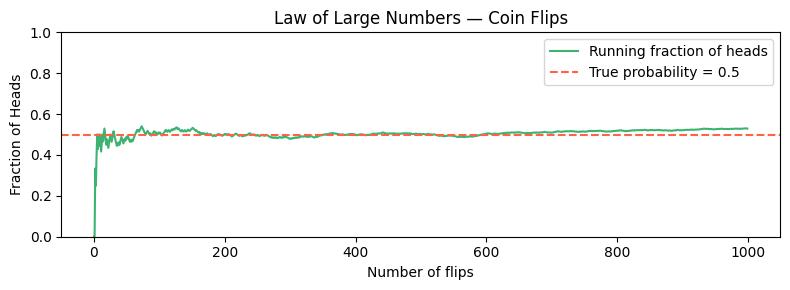

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulate 1000 coin flips (0 = Tails, 1 = Heads)
N = 1000
# np.random.binomial is perfect for this: 1 trial per flip, 50% chance of success
flips = np.random.binomial(n=1, p=0.5, size=N)

# 2. Calculate the running fraction of heads
running_fraction = np.cumsum(flips) / np.arange(1, N + 1)

# 3. Plot the convergence
plt.figure(figsize=(8, 3))
plt.plot(running_fraction, color='mediumseagreen', linewidth=1.5, label='Running fraction of heads')
plt.axhline(0.5, color='tomato', linestyle='--', label='True probability = 0.5')

plt.xlabel('Number of flips'); plt.ylabel('Fraction of Heads')
plt.title('Law of Large Numbers — Coin Flips')
plt.ylim(0, 1)  # Lock Y-axis between 0 and 1 since it's a probability
plt.legend(); plt.tight_layout(); plt.show()

Just like the normal and exponential distributions, a coin flip is governed by the Law of Large Numbers. Each flip is a Bernoulli trial where Heads = 1 and Tails = 0. In the short term, you might flip five heads in a row and shoot the running fraction up to 1.0. But as your sample size approaches 1000, the sheer volume of flips dilutes those early streaks, forcing the running average to flatten out right on the true theoretical probability of 0.5 (or 50%).

## ✅ Exercise
1. Change `mu` and `sigma` in section 2. What happens to the histogram shape?
2. In section 4, replace dice rolls with samples from an exponential distribution (`np.random.exponential`). Does LLN still hold?
3. **Challenge**: simulate 1000 coin flips (0/1). Plot the running fraction of heads. What does it converge to?